# 我使用了什么库？

In [82]:
# 将项目根目录添加到系统路径，以便导入项目中的自定义模块
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [83]:
# 设置Jupyter Notebook的显示样式，将容器宽度限制为80%
from IPython.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [84]:
# ============================================================
# 基础科学计算和图像处理库
# ============================================================
import numpy as np                    # 数值计算库，提供多维数组支持
from PIL import Image                 # 图像读取与处理
from copy import deepcopy             # 深拷贝，用于模型复制

# ============================================================
# PyTorch 核心库
# ============================================================
import torch                          # PyTorch 深度学习框架
import torch.optim as optim           # 优化器模块（SGD, Adam 等）
import torch.nn as nn                 # 神经网络模块（层、损失函数等）
import torch.nn.functional as F       # 函数式API（激活函数、池化等）

# ============================================================
# 数据加载与预处理
# ============================================================
from torch.utils.data import DataLoader, TensorDataset, random_split
# DataLoader: 批量加载数据，支持多线程
# TensorDataset: 将张量包装为数据集
# random_split: 随机划分数据集

# ============================================================
# torchvision 图像变换与数据集
# ============================================================
from torchvision.transforms.v2 import Compose, ToImage, Normalize, \
ToPILImage, Resize, ToDtype
# Compose: 组合多个变换
# ToImage: 将数据转换为图像张量
# Normalize: 图像标准化
# ToPILImage: 张量转PIL图像
# Resize: 调整图像大小
# ToDtype: 转换数据类型

from torchvision.datasets import ImageFolder
# ImageFolder: 按文件夹分类加载图像数据集

# ============================================================
# 学习率调度器
# ============================================================
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau, \
MultiStepLR, CyclicLR, LambdaLR
# StepLR: 等间隔调整学习率
# ReduceLROnPlateau: 指标停滞时降低学习率
# MultiStepLR: 在指定epoch调整学习率
# CyclicLR: 循环学习率
# LambdaLR: 自定义函数调整学习率
# ============================================================
# 项目自定义模块
# ============================================================
from StepClass.v2 import StepByStep   # 训练流程封装类
from data_generation.rps import download_rps  # 下载石头剪刀布数据集

from plots.chapter6 import *           # 第6章绘图函数

In [85]:
plt.style.available

['Solarize_Light2',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'petroff6',
 'petroff8',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

# 然后，我要干什么？

首先要了解下问题的样子

然后了解如何准备相关数据


# 剪刀石头布问题

- 2892个不同手势图像，合成数据集,300x300像素，4个通道RGBA
- 训练集2520图像(rpc)，测试集372图像(rpc-test-set)
- 数据集是完全平衡的

rps folder already exists!
rps-test-set folder already exists!


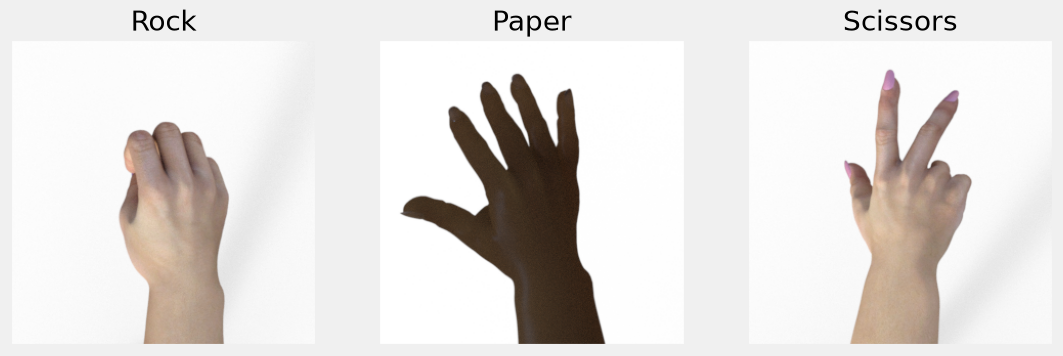

In [86]:
# 下载图片
# 详细逻辑参考bypass
download_rps()

# 展示结果
fig = figure1()

# 数据准备


**Q**: `ImageFolder`需要如何组织数据?

结合代码

**Q**: ImageFolder的参数有那些？

In [87]:
# 程序6-1: ImageFolder的使用和参数
temp_transform = Compose(
    [Resize(28)
     , ToImage()
     , ToDtype(torch.float32, scale=True)
])
temp_dataset = ImageFolder(root='rps', transform=temp_transform)

## 标准化

**Q**: 迁移学习是如何标准化的？

结合代码: 

**Q**: 如何对图片进行标准化?

In [88]:
# 程序6-2 标准化: 统计数量,均值,标准差
@staticmethod
def statistics_per_channel(images, labels):
    n_samples, n_channels, n_height, n_weight = images.size()  # NCHW（批次、通道、高度、宽度）
    #print(n_samples,n_channels,n_height,n_weight) # 16 3 28 28
    flatten_per_channel = images.reshape(n_samples, n_channels, -1)  # 将高和宽展平为单一维度
    #print(flatten_per_channel.shape) #torch.Size([16, 3, 784])

    # 计算每个图像在各通道上的统计信息
    means = flatten_per_channel.mean(axis=2)  # 每个通道的平均像素值 (样本数, 通道数)
    #print(means.shape) # torch.Size([16, 3])

    stds = flatten_per_channel.std(axis=2)  # 每个通道的像素值标准差 (样本数, 通道数)

    # 累加小批量中所有图像的统计信息
    sum_means = means.sum(axis=0)  # (1, 通道数)
    #print(sum_means.shape) # torch.Size([3])
    sum_stds = stds.sum(axis=0)
    # 注意其中的乘号语法
    n_samples = torch.tensor([n_samples]*n_channels).float()  # 创建(1, 通道数)张量，包含小批量中的样本数量
    #print(n_samples)
    
    # 返回数量，均值，标准差
    #print(np.array([n_samples, sum_means, sum_stds]))
    return torch.stack([n_samples, sum_means, sum_stds], axis=0)  # 将三个张量沿第0维堆叠 (3, 通道数)

setattr(StepByStep, 'statistics_per_channel', statistics_per_channel)

In [89]:
# 测试结果

# 临时loader
temp_loader = DataLoader(temp_dataset,batch_size=16)

first_images,first_labels = next(iter(temp_loader))

print(first_images.shape,first_labels.shape)

print(StepByStep.statistics_per_channel(first_images,first_labels))


torch.Size([16, 3, 28, 28]) torch.Size([16])
tensor([[16.0000, 16.0000, 16.0000],
        [13.8748, 13.3048, 13.1962],
        [ 3.0507,  3.8268,  3.9754]])


In [90]:
# 程序6-3: 标准化: 创建标准化器

@staticmethod
def make_normalizer(loader):
    # 对每个批次使用统计函数
    total_samples, total_means, total_stds = StepByStep.loader_apply(loader, StepByStep.statistics_per_channel)
    # 对所有批次的总和求平均
    norm_mean = total_means / total_samples
    norm_std = total_stds / total_samples
    return Normalize(mean=norm_mean, std=norm_std)

setattr(StepByStep, 'make_normalizer', make_normalizer)

In [91]:
# 测试结果

normalizer = StepByStep.make_normalizer(temp_loader)

print(normalizer)

Normalize(mean=[tensor(0.8502), tensor(0.8215), tensor(0.8116)], std=[tensor(0.2089), tensor(0.2512), tensor(0.2659)], inplace=False)


## 真实数据集

**Q**: 标准化使用哪部分的数据？

结合代码: 

**Q**: 如何对图片进行标准化?

In [92]:
# 程序6-4: 利用生成标准化器标准化图片

# 将图片转为张量并标准化
composer = Compose([Resize(28),
                    ToImage(),
                    ToDtype(torch.float32, scale=True),
                    normalizer])

# 构建DataSet
train_data = ImageFolder(root='rps', transform=composer)
val_data = ImageFolder(root='rps-test-set', transform=composer)

# 构建loader
# 注意打乱数据
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)

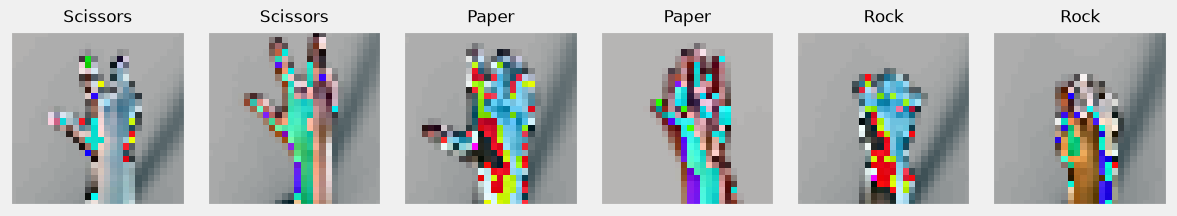

In [93]:
# 测试结果

torch.manual_seed(88)
first_images, first_labels = next(iter(train_loader))

fig = figure2(first_images, first_labels)

# 然后，我要干什么？

注意到现在处理的是三通道数据，结合上一张的卷积知识，自然想到三通道的卷积应该怎么做？


# 三通道卷积

**Q**: 多通道卷积的计算方式是什么？

**Q**: 多个多通道滤波器会产生什么结果？

结合代码:

**Q**: 如何使用卷积计算?

In [94]:
# 程序6-5: 模拟三通道卷积的计算

# 数据
regions = np.array([[[[5, 0, 8],
                      [1, 9, 5],
                      [6, 0, 2]],
                     [[0, 5, 4],
                      [8, 1, 9],
                      [4, 8, 1]],
                     [[4, 2, 0],
                      [6, 3, 0],
                      [5, 2, 8]]]])
print(regions.shape)

# 滤波器
three_channel_filter = np.array([[[[0, 3, 0],
                                   [1, 0, 1],
                                   [2, 1, 0]],
                                  [[2, 1, 0],
                                   [0, 3, 1],
                                   [1, -1, 0]],
                                  [[0, 1, 3],
                                   [-1, -2, 0],
                                   [2, 0, 1]]]])
print(three_channel_filter.shape)


# 函数式应用
result = F.conv2d(torch.as_tensor(regions), torch.as_tensor(three_channel_filter))
print(result, result.shape)

(1, 3, 3, 3)
(1, 3, 3, 3)
tensor([[[[39]]]]) torch.Size([1, 1, 1, 1])


# BTW(By the way)

按理应该利用卷积+池化+激活函数创建一个模型类，但是先要了解一个通用的概念：DropOut

# 丢弃: DropOut

**Q**: 正则化的思想是什么？

**Q**: 丢弃是什么？其目的是什么？



结合代码:

**Q**: 如何使用DropOut? 

**Q**: Dropout 在训练模式下做了哪两件事？为什么要这么做？

**Q**: 丢弃的对象是什么？权重还是输入？


---



In [95]:
# 程序6-6: DropOut的使用

# 设定丢弃概率
# F.dropout
dropping_model = nn.Sequential(nn.Dropout(p=0.5))

# 创建等距的分割
spaced_points = torch.linspace(.1, 1.1, 11)
print(spaced_points)

torch.manual_seed(44)

# 注意要切换模式
dropping_model.train()

# 测试结果: 随机丢弃
output_train = dropping_model(spaced_points)
print(output_train)

tensor([0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000, 0.9000,
        1.0000, 1.1000])
tensor([0.0000, 0.0000, 0.6000, 0.8000, 0.0000, 0.0000, 1.4000, 0.0000, 1.8000,
        2.0000, 2.2000])


In [96]:
# 程序6-7: 计算dropOut的缩放倍率

print(output_train/spaced_points)

tensor([0., 0., 2., 2., 0., 0., 2., 0., 2., 2., 2.])


In [97]:
# 程序6-8: DropOut的评价模式


dropping_model.eval()
output_eval = dropping_model(spaced_points)
print(output_eval)


tensor([0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000, 0.9000,
        1.0000, 1.1000])


## DropOut下的分布

结合图:

**Q**: 模型学习的数值分布以什么为中心？

**Q**: DropOut率对输出形状的影响？


In [98]:
# 对比训练和评价模式的分布

print(F.linear(output_train, weight=torch.ones(11), bias=torch.tensor(0)))

print(F.linear(output_eval, weight=torch.ones(11), bias=torch.tensor(0)))


tensor(8.8000)
tensor(6.6000)


In [99]:
# 统计DropOut的分布情况: 生成数据

torch.manual_seed(17)
p = 0.5

# 列表推导式，生成1000次dropout场景，统计分布
distrib_outputs = torch.tensor(
    [F.linear(F.dropout(spaced_points, p=p)
              ,weight=torch.ones(11), bias=torch.tensor(0))
                for _ in range(1000)
    ])

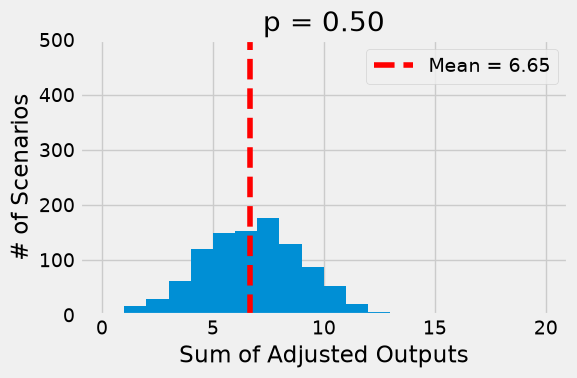

In [100]:
# 统计DropOut的分布情况: 作图
fig = figure7(p, distrib_outputs)

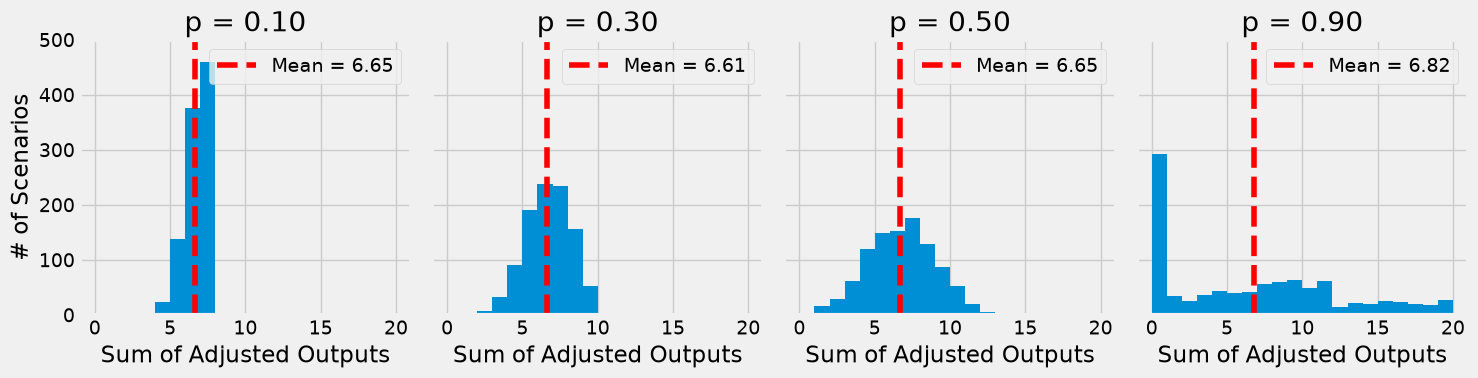

In [101]:
# 不同DropOut率对结果的影响
fig = figure8()

## 二维DropOut

**Q**: 在卷积过程中丢弃的对象是什么？

**Q**: 和普通DropOut的区别是什么？表现上有什么区别？

**Q**: 使用的类是什么？


torch.Size([1, 3, 28, 28])


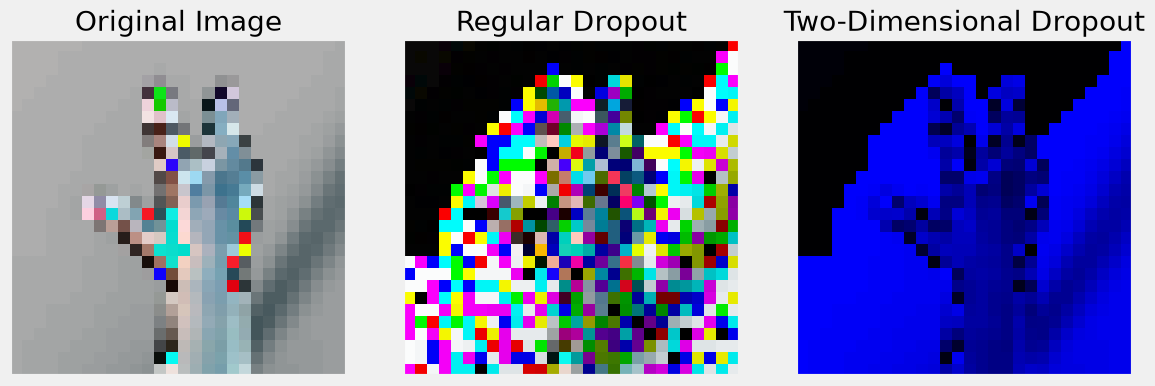

In [102]:
# 展示丢弃
print(first_images[:1].shape)
fig = figure9(first_images)

# 然后，我要干什么？

回到正题，现在可以更新一个处理图像的模型类了

# 更高级的模型

结合代码:

**Q**: 卷积的前向传播有哪些步骤？具体步骤是什么？

In [103]:
# 程序6-9: CNN2模型定义

class CNN2(nn.Module):
    def __init__(self, n_feature, p=0.0):
        super(CNN2, self).__init__()
        self.n_feature = n_feature
        self.p = p
        # 创建卷积层
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_feature, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=n_feature, out_channels=n_feature, kernel_size=3)
        # 创建全连接层
        # 这个 5 * 5 从哪来的？！看下面
        self.fc1 = nn.Linear(n_feature * 5 * 5, 50) 
        self.fc2 = nn.Linear(50, 3)
        # 创建 Dropout 层
        self.drop = nn.Dropout(self.p)
        
    def featurizer(self, x):
        # 特征提取器
        # 第一个卷积块
        # 3@28x28 -> n_feature@26x26 -> n_feature@13x13
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)
        # 第二个卷积块
        # n_feature@13x13 -> n_feature@11x11 -> n_feature@5x5
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)
        # 拉平
        # 输入维度 (n_feature@5x5)
        # 输出维度 (n_feature * 5 * 5)
        x = nn.Flatten()(x)
        return x
    
    def classifier(self, x):
        # 分类器
        # 隐藏层
        # 输入维度 (n_feature * 5 * 5)
        # 输出维度 (50)
        if self.p > 0:
            x = self.drop(x)
        x = self.fc1(x)
        x = F.relu(x)
        # 输出层
        # 输入维度 (50)
        # 输出维度 (3)
        if self.p > 0:
            x = self.drop(x)
        x = self.fc2(x)
        return x
                
    # 前向预测
    def forward(self, x):
        x = self.featurizer(x) # 特征提取(展平)
        x = self.classifier(x) # 分类
        return x

# 模型配置

计划: 滤波器5个，30%丢失概率，交叉熵误差

暂时搁置: 放弃使用SGD优化器，使用Adam进行更改（自适应学习率）

**Q**: 模型配置的内容有哪些？

**Q**: Karpathy常数是什么？多少？

结合代码:

**Q**: 模型,优化器和误差函数如何使用？



In [104]:
# 程序6-10: 模型配置

torch.manual_seed(13)
model_cnn2 = CNN2(n_feature=5, p=0.3)
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
optimizer_cnn2 = optim.Adam(model_cnn2.parameters(), lr=3e-4)

# 模型训练

结合代码：

**Q**: 如何使用模型训练？

**Q**: 如何绘制损失？

In [105]:
# 程序6-11: 模型训练

sbs_cnn2 = StepByStep(model_cnn2, multi_loss_fn, optimizer_cnn2)
sbs_cnn2.set_loaders(train_loader, val_loader)
sbs_cnn2.train(10)

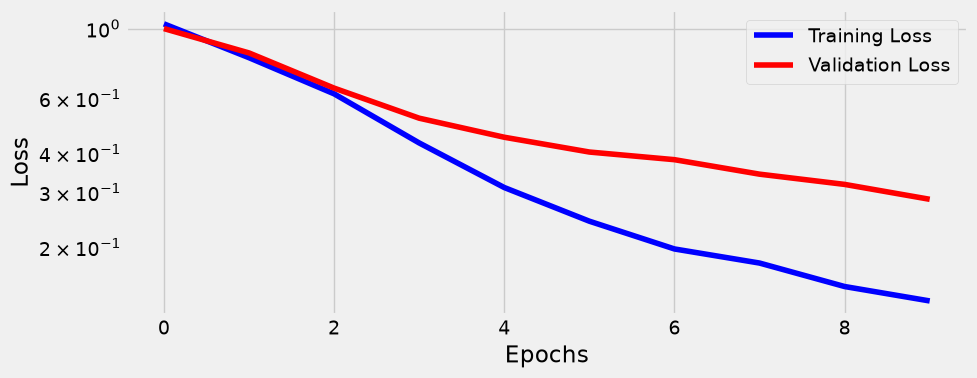

In [106]:
# 程序6-12: 测试损失
fig = sbs_cnn2.plot_losses()

In [ ]:
# 程序6-13: 准确率

# 372中317个 85.2%
StepByStep.loader_apply(val_loader, sbs_cnn2.correct)

tensor([[ 88, 124],
        [118, 124],
        [111, 124]])

## 对比DropOut的效果


结合图和准确率数据

**Q**: 丢弃的正则化效果是如何表现的？

**Q**: 没有丢弃的模型，对于训练数据会发生什么？

In [108]:
# 建立非Drop的模型

torch.manual_seed(13)
# Model Configuration
model_cnn2_nodrop = CNN2(n_feature=5, p=0.0)
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
optimizer_cnn2_nodrop = optim.Adam(model_cnn2_nodrop.parameters(), lr=3e-4)
# Model Training
sbs_cnn2_nodrop = StepByStep(model_cnn2_nodrop, multi_loss_fn, optimizer_cnn2_nodrop)
sbs_cnn2_nodrop.set_loaders(train_loader, val_loader)
sbs_cnn2_nodrop.train(10)

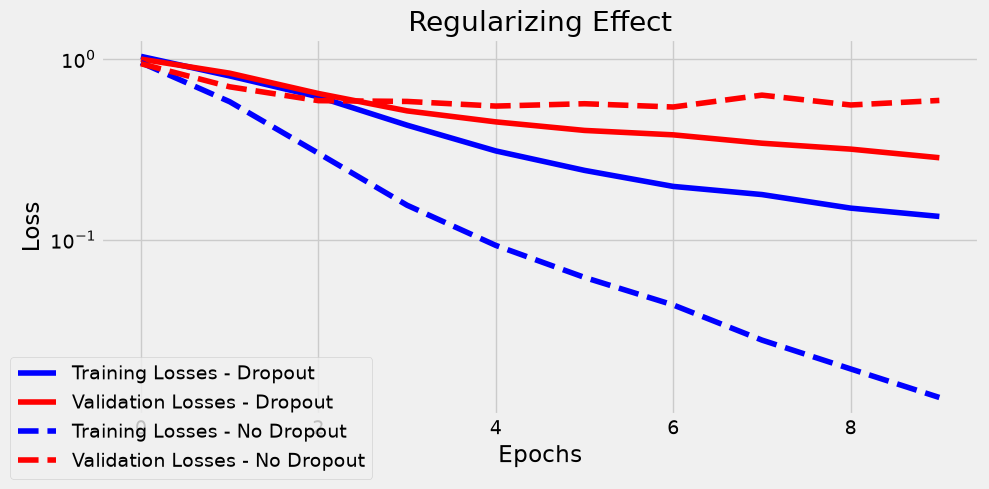

In [109]:
# 对比结果
fig = figure11(sbs_cnn2.losses, sbs_cnn2.val_losses, sbs_cnn2_nodrop.losses, sbs_cnn2_nodrop.val_losses)

In [110]:
# 对比准确率
print(
    StepByStep.loader_apply(train_loader, sbs_cnn2_nodrop.correct).sum(axis=0), 
    StepByStep.loader_apply(val_loader, sbs_cnn2_nodrop.correct).sum(axis=0)
)

print(
    StepByStep.loader_apply(train_loader, sbs_cnn2.correct).sum(axis=0),
    StepByStep.loader_apply(val_loader, sbs_cnn2.correct).sum(axis=0)
)

tensor([2520, 2520]) tensor([293, 372])
tensor([2498, 2520]) tensor([317, 372])


# 可视化滤波器

结合输出:

**Q**：解释滤波器形状变化的意思？

In [ ]:
# 滤波器形状
print(model_cnn2.conv1.weight.shape) # 3->5

print(model_cnn2.conv2.weight.shape) # 5->5

torch.Size([5, 3, 3, 3])
torch.Size([5, 5, 3, 3])


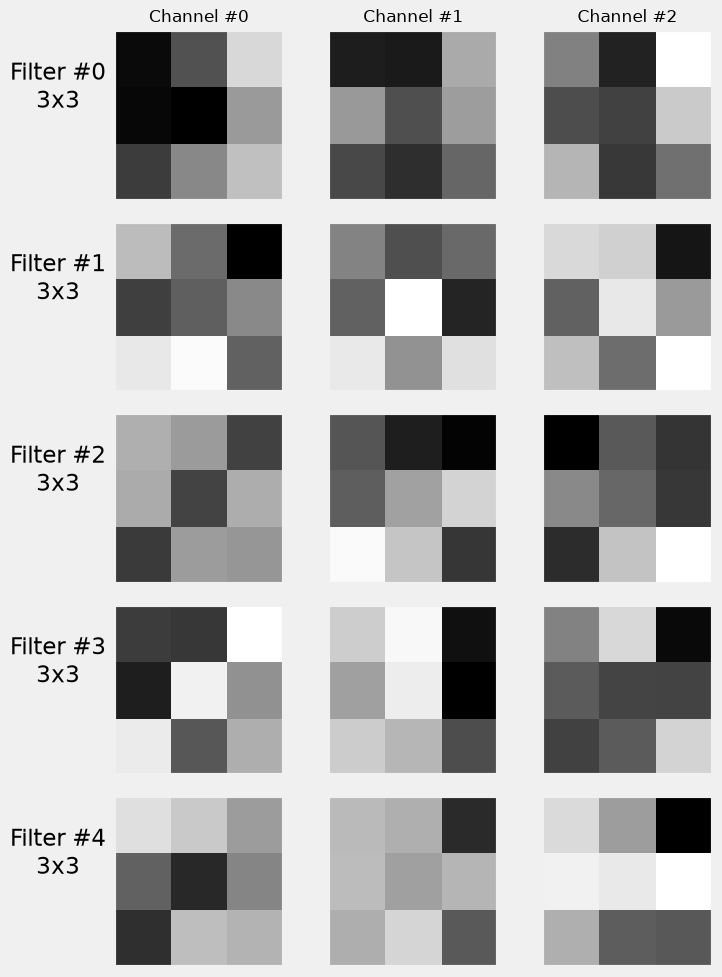

In [ ]:
# 可视化滤波器1
fig = sbs_cnn2.visualize_filters('conv1')

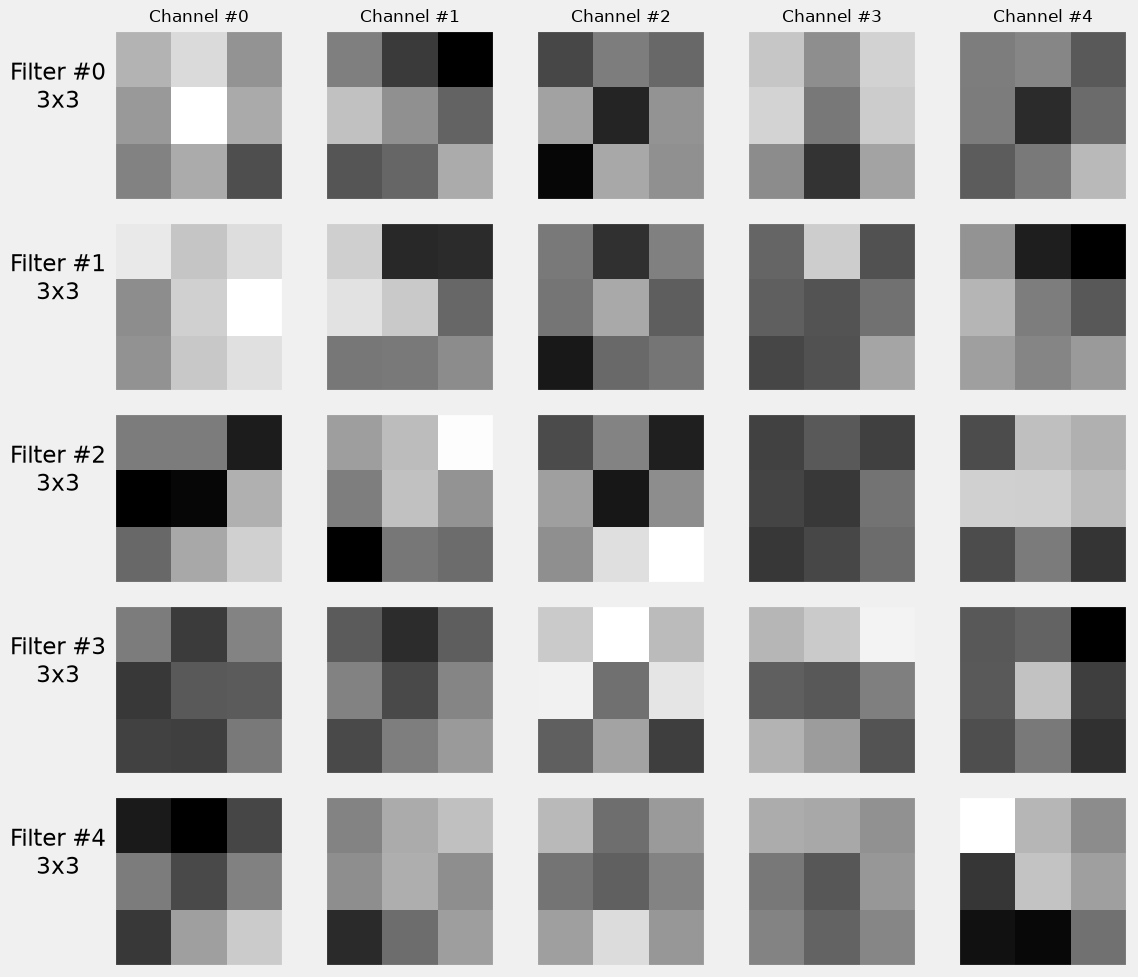

In [114]:
# 可视化滤波器2
fig = sbs_cnn2.visualize_filters('conv2')